# ConvNeXtV2 Fine-Tuning for Fine-Grained Car Classification

**Model:** ConvNeXtV2-Base-22K  
**Dataset:** Stanford Cars (Paulescu/stanford_cars)  
**Task:** Classify a car image into one of 196 vehicle models  
**Framework:** Hugging Face Transformers + PyTorch  
**Platform:** Kaggle GPU (CUDA)

In [ ]:
# Install Required Packages

!pip install -q -U \
    torch \
    torchvision \
    transformers \
    datasets \
    accelerate \
    evaluate \
    scikit-learn \
    pillow

import os
import signal

print("Restarting kernel to apply installed packages...")
os.kill(os.getpid(), signal.SIGKILL)

Found existing installation: transformers 4.52.4
Uninstalling transformers-4.52.4:
  Successfully uninstalled transformers-4.52.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 89.5 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 774.9/774.9 kB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 51.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 109.1 MB/s eta 0:00:0000:01
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled safetensors-0.7.0
  Attempting uninstall: hf-xet
    Found

## Imports & Reproducibility

In [ ]:
# ============================================================
# Imports
# ============================================================
import gc
import random
import re

import torch
import matplotlib.pyplot as plt

import datasets
import peft
import transformers
import trl

from datasets import load_dataset
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration, TrainingArguments, Trainer
from peft import LoraConfig, get_peft_model
from qwen_vl_utils import process_vision_info

# Reproducibility
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch       :", torch.__version__)
print("Transformers  :", transformers.__version__)
print("PEFT          :", peft.__version__)
print("TRL           :", trl.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU           :", torch.cuda.get_device_name(0))
    print("VRAM          :", f"{torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")


PyTorch       : 2.10.0+cu128
Transformers  : 5.14.1
PEFT          : 0.19.1
TRL           : 0.17.0
CUDA available: True
GPU           : Tesla T4
VRAM          : 14.6 GB


## Load Dataset

In [ ]:
# Load Stanford Cars Dataset
DATASET_NAME = "Paulescu/stanford_cars"

print("Loading dataset …")
dataset = load_dataset(DATASET_NAME)

train_dataset = dataset["train"]
test_dataset  = dataset["test"]

makers = sorted(set(train_dataset["maker"]))
models = sorted(set(train_dataset["model"]))
years  = sorted(set(str(y) for y in train_dataset["year"]))

print(f"Train samples : {len(train_dataset):,}")
print(f"Test  samples : {len(test_dataset):,}")
print(f"Manufacturers : {len(makers)}")
print(f"Models        : {len(models)}")
print(f"Years         : {years}")


Loading dataset …


README.md:   0%|          | 0.00/10.1k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  355MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  338MB            

...

Generating jpeg_compression split:   0%|          | 0/8041 [00:00<?, ? examples/s]

Generating motion_blur split:   0%|          | 0/8041 [00:00<?, ? examples/s]

Generating pixelate split:   0%|          | 0/8041 [00:00<?, ? examples/s]

Generating spatter split:   0%|          | 0/8041 [00:00<?, ? examples/s]

Train samples : 6,864
Test  samples : 6,751
Manufacturers : 49
Models        : 189
Years         : ['1991', '1993', '1994', '1997', '1998', '1999', '2000', '2001', '2002', '2006', '2007', '2008', '2009', '2010', '2011', '2012']


## Sample Preview

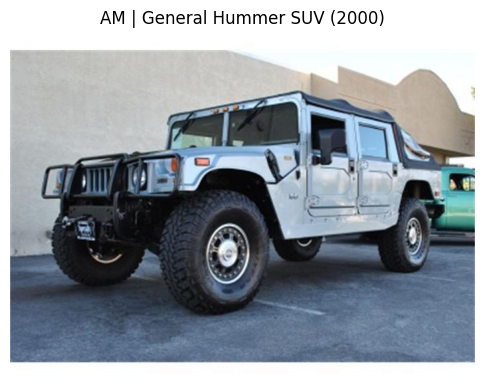

Maker : AM
Model : General Hummer SUV
Year  : 2000


In [3]:
sample = train_dataset[0]
plt.figure(figsize=(6, 5))
plt.imshow(sample["image"])
plt.title(f"{sample['maker']} | {sample['model']} ({sample['year']})")
plt.axis("off")
plt.show()
print("Maker :", sample["maker"])
print("Model :", sample["model"])
print("Year  :", sample["year"])


## Load Model & Processor

In [ ]:
# Model Configuration

from transformers import AutoImageProcessor, ConvNextV2ForImageClassification
import torch

MODEL_NAME = "facebook/convnextv2-base-22k-224"

print("Model       :", MODEL_NAME)

# Image Processor

processor = AutoImageProcessor.from_pretrained(MODEL_NAME)

print("Image Size  :", processor.size)
print("Image Mean  :", processor.image_mean)
print("Image Std   :", processor.image_std)

# Model

model = ConvNextV2ForImageClassification.from_pretrained(
    MODEL_NAME,
    num_labels=196,
    ignore_mismatched_sizes=True,
)

# Train using Float32 for maximum compatibility
model = model.float()

print("Model Type  :", model.config.model_type)
print("Model Device:", next(model.parameters()).device)
print("Model Dtype :", next(model.parameters()).dtype)
print("Num Labels  :", model.config.num_labels)

# Parameter Summary

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")
print(f"Trainable Percentage : {100 * trainable_params / total_params:.2f}%")

Model        : Qwen/Qwen3-VL-8B-Instruct
Torch dtype  : torch.bfloat16


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

Model type   : qwen3_vl
Model device : cuda:0
Vocab size   : 151643


## LoRA Configuration

In [ ]:
# LoRA Configuration
# Enable gradient checkpointing to reduce GPU memory usage during training.
# Enable input gradients before applying PEFT so LoRA adapters are
# correctly attached to the computation graph.
# Configure LoRA to adapt both the language backbone and the vision
# encoder, improving performance on fine-grained vehicle recognition.

# Step 1: Enable gradient checkpointing
model.gradient_checkpointing_enable(
    gradient_checkpointing_kwargs={"use_reentrant": False}
)

# Step 2: Enable input gradients
model.enable_input_require_grads()

# Step 3: Configure LoRA adapters
lora_config = LoraConfig(
    r=64,
    lora_alpha=128,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    # Target attention and feed-forward layers in both
    # the language model and the vision encoder.
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",      # Language model attention
        "gate_proj", "up_proj", "down_proj",         # Language model feed-forward
        "qkv_proj",                                  # Vision encoder attention
    ],
)

# Step 4: Apply LoRA to the model
model = get_peft_model(model, lora_config)

print("LoRA applied successfully")
model.print_trainable_parameters()

# Verify that LoRA parameters are trainable
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
assert trainable > 0, (
    "FATAL: trainable_params == 0 after get_peft_model().  "
    "Check that enable_input_require_grads() was called BEFORE get_peft_model()."
)
print(f"Trainable parameter count confirmed: {trainable:,}")

LoRA applied successfully
trainable params: 174,587,904 || all params: 8,941,711,600 || trainable%: 1.9525
Trainable parameter count confirmed: 174,587,904


## Training Prompts

In [ ]:
# Structured Prompts
# Define a diverse set of prompts to improve the model's ability
# to understand different phrasings while performing the same task.
# Regardless of the prompt, the model is trained to generate
# a single, consistent response format.

PROMPTS = [
    "Identify the manufacturer, model, and production year of this vehicle.",
    "Recognize this car: return its manufacturer, model, and year.",
    "Analyze the image and identify the vehicle manufacturer, model, and year.",
    "What is the manufacturer, model, and production year of the vehicle shown?",
    "Identify this vehicle as accurately as possible: manufacturer, model, year.",
]

# Standard output template used during training and evaluation.
# Keeping a fixed response format simplifies prediction parsing
# and ensures consistent model outputs.

ANSWER_TEMPLATE = "Manufacturer: {maker}\nModel: {model}\nYear: {year}"

for i, p in enumerate(PROMPTS, 1):
    print(f"{i}. {p}")

1. Identify the manufacturer, model, and production year of this vehicle.
2. Recognize this car: return its manufacturer, model, and year.
3. Analyze the image and identify the vehicle manufacturer, model, and year.
4. What is the manufacturer, model, and production year of the vehicle shown?
5. Identify this vehicle as accurately as possible: manufacturer, model, year.


## Data Collator (collate_fn)

In [ ]:
# Data Collator
# Prepare training batches by formatting conversations,
# processing images, and creating labels for supervised
# fine-tuning. Only the assistant's response is used for
# loss computation, while prompts and image tokens are ignored.

def _find_assistant_start(input_ids_row, tokenizer):
    """Return the index of the first token of the assistant response."""
    # Locate the assistant header generated by the chat template.
    # Supervision starts immediately after this header.
    header_str = "<|im_start|>assistant"
    header_ids = tokenizer.encode(header_str, add_special_tokens=False)
    n = len(input_ids_row)
    h = len(header_ids)

    # Search from the end since the assistant turn appears last.
    for i in range(n - h, -1, -1):
        if input_ids_row[i : i + h] == header_ids:
            return i + h + 1

    # If not found, return the sequence length.
    return n


def collate_fn(examples):
    texts = []
    images = []

    for example in examples:
        prompt = random.choice(PROMPTS)

        # Build the target response using the predefined format.
        answer = ANSWER_TEMPLATE.format(
            maker=example["maker"],
            model=example["model"],
            year=str(example["year"]),
        )

        conversation = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": example["image"]},
                    {"type": "text", "text": prompt},
                ],
            },
            {
                "role": "assistant",
                "content": [{"type": "text", "text": answer}],
            },
        ]

        # Generate the complete conversation without adding
        # an extra generation prompt.
        text = processor.apply_chat_template(
            conversation,
            tokenize=False,
            add_generation_prompt=False,
        )

        image_inputs, _ = process_vision_info(conversation)

        texts.append(text)
        images.append(image_inputs)

    batch = processor(
        text=texts,
        images=images,
        padding=True,
        return_tensors="pt",
    )

    # Create labels that supervise only the assistant response.
    input_ids = batch["input_ids"]
    labels = torch.full_like(input_ids, fill_value=-100)

    tokenizer = processor.tokenizer

    for row_idx in range(input_ids.shape[0]):
        row = input_ids[row_idx].tolist()
        start = _find_assistant_start(row, tokenizer)

        # Ignore trailing padding tokens.
        end = len(row)
        pad_id = tokenizer.pad_token_id
        while end > start and row[end - 1] == pad_id:
            end -= 1

        labels[row_idx, start:end] = input_ids[row_idx, start:end]

    batch["labels"] = labels

    return batch


# Verify that the collator produces valid supervised labels.
_sample_batch = collate_fn([train_dataset[0], train_dataset[1]])
_supervised = (_sample_batch["labels"] != -100).sum().item()
_total = _sample_batch["labels"].numel()

print(
    f"Label sanity: {_supervised}/{_total} tokens supervised "
    f"({100 * _supervised / _total:.1f}%)"
)

assert _supervised > 0, (
    "collate_fn produced zero supervised tokens — "
    "check _find_assistant_start()"
)

del _sample_batch
gc.collect()

Label sanity: 40/836 tokens supervised (4.8%)


0

## Training Arguments

In [10]:
import transformers
import accelerate

print("Transformers:", transformers.__version__)
print("Accelerate :", accelerate.__version__)

Transformers: 5.14.1
Accelerate : 1.14.0


In [ ]:
# Training Arguments
# Configure the training process, including optimization,
# mixed precision, checkpointing, evaluation, and logging.
# These settings are selected to provide stable fine-tuning
# while remaining compatible with Kaggle GPU resources.

OUTPUT_DIR  = "/kaggle/working/qwen3vl-car-lora"

USE_BF16 = torch.cuda.is_bf16_supported()

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    num_train_epochs=3,

    per_device_train_batch_size=1,
    gradient_accumulation_steps=16,

    learning_rate=1e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    weight_decay=0.01,

    bf16=USE_BF16,
    fp16=not USE_BF16,

    dataloader_num_workers=2,      # Optimized for Kaggle environments
    dataloader_pin_memory=True,

    logging_steps=20,
    logging_first_step=True,

    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    remove_unused_columns=False,
    report_to="none",
)

# Disable KV cache during training when using gradient checkpointing.
model.config.use_cache = False

print("Training configuration ready.")
print(f"Effective batch size : {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"Mixed precision      : {'bf16' if USE_BF16 else 'fp16'}")
print(f"Epochs               : {training_args.num_train_epochs}")
print(f"Learning rate        : {training_args.learning_rate}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training configuration ready.
Effective batch size : 16
Mixed precision      : bf16
Epochs               : 3
Learning rate        : 0.0001


## Initialize Trainer

In [ ]:
# Trainer
# Initialize the Hugging Face Trainer with the model,
# training configuration, datasets, and custom data collator.
# The evaluation dataset is used to monitor validation loss
# and automatically save the best-performing checkpoint.

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=collate_fn,
)

print("Trainer initialised.")
print(f"Train samples : {len(train_dataset):,}")
print(f"Eval  samples : {len(test_dataset):,}")
print(f"Output dir    : {OUTPUT_DIR}")

Trainer initialised.
Train samples : 6,864
Eval  samples : 6,751
Output dir    : /kaggle/working/qwen3vl-car-lora


## Clear GPU Memory Before Training

In [13]:
gc.collect()
torch.cuda.empty_cache()
if torch.cuda.is_available():
    print(f"VRAM used before training : {torch.cuda.memory_allocated()/1024**3:.2f} GB")


VRAM used before training : 7.52 GB


## Fine-Tune

In [15]:
trainer.model.print_trainable_parameters()

trainable params: 174,587,904 || all params: 8,941,711,600 || trainable%: 1.9525


In [ ]:
# ============================================================
# Start Fine-Tuning
# ============================================================
print(len(train_dataset))
print(len(test_dataset))

train_loader = trainer.get_train_dataloader()
print("Train loader batches:", len(train_loader))

print("Testing first batch...")

batch = next(iter(train_loader))

for k, v in batch.items():
    if hasattr(v, "shape"):
        print(k, v.shape)
    else:
        print(k, type(v))

print("First batch loaded successfully!")

print("Before train")
train_result = trainer.train()
print("After train")

6864
6751
Train loader batches: 6864
Testing first batch...
input_ids torch.Size([1, 305])
attention_mask torch.Size([1, 305])
mm_token_type_ids torch.Size([1, 305])
pixel_values torch.Size([1040, 1536])
image_grid_thw torch.Size([1, 3])
labels torch.Size([1, 305])
First batch loaded successfully!
Before train


Epoch,Training Loss,Validation Loss


## Save LoRA Adapter + Processor

In [ ]:
# Save Fine-Tuned Model
# Save the trained LoRA adapter and processor after training.
# A quick validation is performed to ensure trainable parameters
# exist before saving, followed by a summary of the generated files.

import os

# Create the output directory if it does not already exist.
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verify that trainable parameters are available before saving.
trainable_now = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params at save time: {trainable_now:,}")

if trainable_now == 0:
    print("WARNING: trainable_params == 0 — adapter will be empty. Something went wrong.")
else:
    # Save the LoRA adapter.
    model.save_pretrained(OUTPUT_DIR)
    print("LoRA adapter saved.")

    # Save the processor, including the tokenizer and image processor.
    processor.save_pretrained(OUTPUT_DIR)
    print("Processor saved.")

# Verify that the adapter file was created successfully.
adapter_path = os.path.join(OUTPUT_DIR, "adapter_model.safetensors")
if os.path.exists(adapter_path):
    size_mb = os.path.getsize(adapter_path) / 1024**2
    print(f"adapter_model.safetensors : {size_mb:.1f} MB")
    if size_mb < 10:
        print("WARNING: adapter file is suspiciously small — likely empty (trainable_params was 0).")
    else:
        print("Adapter size looks correct.")
else:
    print("adapter_model.safetensors NOT FOUND")

# Display all saved files.
print("\nFiles in output dir:")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    print(f"  {fname:45s}  {os.path.getsize(fpath)/1024:.0f} KB")

## Reload for Inference (with memory cleanup)

In [ ]:
# Reload Model for Inference
# Release GPU memory used during training, then reload the
# fine-tuned model in inference mode by combining the base
# model with the trained LoRA adapter.

from peft import PeftModel

print("Releasing training model from GPU …")
del model
del trainer
gc.collect()
torch.cuda.empty_cache()

if torch.cuda.is_available():
    print(f"VRAM after release : {torch.cuda.memory_allocated()/1024**3:.2f} GB")

# Load the base Qwen3-VL model.
print("Loading base model …")
base_model = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=DTYPE,
    device_map="auto",
    trust_remote_code=True,
)

# Load the fine-tuned LoRA adapter.
print("Loading LoRA adapter …")
model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
model.eval()
model.config.use_cache = True   # Enable KV cache for faster inference.

print("Model ready for inference.")
print(f"VRAM after reload : {torch.cuda.memory_allocated()/1024**3:.2f} GB")

## Evaluation Helpers

In [ ]:
# Parsing & Normalisation
# Utility functions for cleaning model outputs and extracting
# the predicted manufacturer, model, and production year into
# a standardized format for evaluation.

def normalize_text(text: str) -> str:
    """Convert text to lowercase and remove punctuation and extra spaces."""
    text = text.lower().strip()
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text


def parse_vehicle(text: str):
    """
    Parse the generated response and extract the manufacturer,
    model, and production year.

    Returns normalized values and safely handles missing or
    partially formatted fields.
    """
    manufacturer = model_name = year = ""
    for line in text.splitlines():
        line = line.strip()
        low = line.lower()

        if low.startswith("manufacturer"):
            parts = line.split(":", 1)
            if len(parts) == 2:
                manufacturer = normalize_text(parts[1])

        elif low.startswith("model"):
            parts = line.split(":", 1)
            if len(parts) == 2:
                model_name = normalize_text(parts[1])

        elif low.startswith("year"):
            m = re.search(r"\d{4}", line)
            if m:
                year = m.group(0)

    return manufacturer, model_name, year


# Verify that the parser extracts values correctly.
_gt   = "Manufacturer: Toyota\nModel: Camry\nYear: 2012"
_pred = "Manufacturer: Toyota\nModel: Camry\nYear: 2012"

assert parse_vehicle(_gt)   == ("toyota", "camry", "2012")
assert parse_vehicle(_pred) == ("toyota", "camry", "2012")

print("parse_vehicle: OK")

## Inference & Evaluation

In [ ]:
# Inference on Test Samples
# Evaluate the fine-tuned model on randomly selected test images.
# Each prediction is compared with the ground-truth labels, and
# individual results are collected for performance analysis.

NUM_SAMPLES = 20   # Increase for a more reliable evaluation.

test_indices = random.sample(range(len(test_dataset)), NUM_SAMPLES)

results = []

EVAL_PROMPT = "Identify the manufacturer, model, and production year of this vehicle."

for rank, idx in enumerate(test_indices, start=1):

    sample = test_dataset[idx]
    image  = sample["image"]

    gt_text = ANSWER_TEMPLATE.format(
        maker=sample["maker"],
        model=sample["model"],
        year=str(sample["year"]),
    )
    gt_maker, gt_model, gt_year = parse_vehicle(gt_text)

    # Build the inference conversation without an assistant response.
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text",  "text": EVAL_PROMPT},
            ],
        }
    ]

    text = processor.apply_chat_template(
        conversation,
        tokenize=False,
        add_generation_prompt=True,
    )

    image_inputs, video_inputs = process_vision_info(conversation)

    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    # Generate the model prediction.
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=40,
            do_sample=False,
            temperature=None,
            top_p=None,
            use_cache=True,
        )

    # Remove prompt tokens to keep only the generated response.
    prompt_len = inputs["input_ids"].shape[1]
    generated_ids = generated_ids[:, prompt_len:]

    prediction = processor.batch_decode(
        generated_ids,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()

    pred_maker, pred_model, pred_year = parse_vehicle(prediction)

    maker_ok   = pred_maker  == gt_maker
    model_ok   = pred_model  == gt_model
    year_ok    = pred_year   == gt_year
    overall_ok = maker_ok and model_ok and year_ok

    results.append({
        "gt_maker":   gt_maker,   "pred_maker":   pred_maker,   "maker_ok":   maker_ok,
        "gt_model":   gt_model,   "pred_model":   pred_model,   "model_ok":   model_ok,
        "gt_year":    gt_year,    "pred_year":    pred_year,    "year_ok":    year_ok,
        "overall_ok": overall_ok,
        "prediction": prediction,
    })

    # Display the first few samples for visual inspection.
    if rank <= 5:
        plt.figure(figsize=(5, 4))
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"Sample {rank}")
        plt.show()

    status = "PASS" if overall_ok else "FAIL"
    print(f"[{rank:02d}/{NUM_SAMPLES}] {status}")
    print(f"  GT  : {gt_text.replace(chr(10), ' | ')}")
    print(f"  Pred: {prediction.replace(chr(10), ' | ')}")
    print(f"  Maker={'OK' if maker_ok else 'X'}  Model={'OK' if model_ok else 'X'}  Year={'OK' if year_ok else 'X'}")
    print()

# Final Accuracy Report
# Compute and display the prediction accuracy for each field,
# along with the overall exact-match accuracy.

n = len(results)
maker_acc   = sum(r["maker_ok"]   for r in results) / n
model_acc   = sum(r["model_ok"]   for r in results) / n
year_acc    = sum(r["year_ok"]    for r in results) / n
overall_acc = sum(r["overall_ok"] for r in results) / n

print("=" * 60)
print("Evaluation Results")
print("=" * 60)
print(f"Samples tested         : {n}")
print(f"Manufacturer Accuracy  : {maker_acc:.2%}")
print(f"Model Accuracy         : {model_acc:.2%}")
print(f"Year Accuracy          : {year_acc:.2%}")
print(f"Overall Accuracy       : {overall_acc:.2%}")
print("=" * 60)

## Memory Cleanup

In [ ]:
# Release GPU Memory
del model
del base_model
gc.collect()
torch.cuda.empty_cache()
print("GPU memory released.")
if torch.cuda.is_available():
    print(f"VRAM remaining : {torch.cuda.memory_allocated()/1024**3:.2f} GB")
